# Домашнее задание к занятию «Работа с переменными»

Выполнил: Ярослав Золотухин

In [59]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [60]:
housing = fetch_california_housing(as_frame=True)
housing.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


Пропуски отсутствуют.

In [61]:
y = housing.target
X = housing.data

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
model = LinearRegression()
model.fit( X_train, y_train )

LinearRegression()

In [64]:
y_pred = model.predict(X_test)

In [65]:
MSE = mean_squared_error(y_test, y_pred)
RMSE = math.sqrt(MSE)
print(f"RMSE: {RMSE:.4f}")

RMSE: 0.7456


In [66]:
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2}")

R²: 0.5757877060324508


## График распределения целевой переменной

(array([4489., 7870., 4568., 1991., 1722.]),
 array([0.14999 , 1.119994, 2.089998, 3.060002, 4.030006, 5.00001 ]),
 <BarContainer object of 5 artists>)

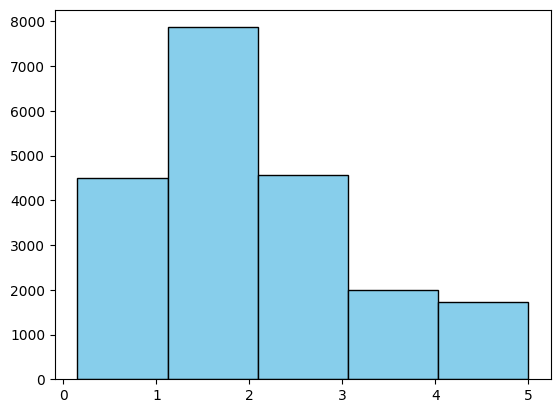

In [67]:
plt.hist(y, bins=5, color='skyblue', edgecolor='black')

{'whiskers': [<matplotlib.lines.Line2D at 0x1295e97c0>,
 'caps': [<matplotlib.lines.Line2D at 0x1295e9d00>,
 'boxes': [<matplotlib.lines.Line2D at 0x1295e9490>],
 'medians': [<matplotlib.lines.Line2D at 0x1295f8280>],
 'fliers': [<matplotlib.lines.Line2D at 0x1295f8520>],
 'means': []}

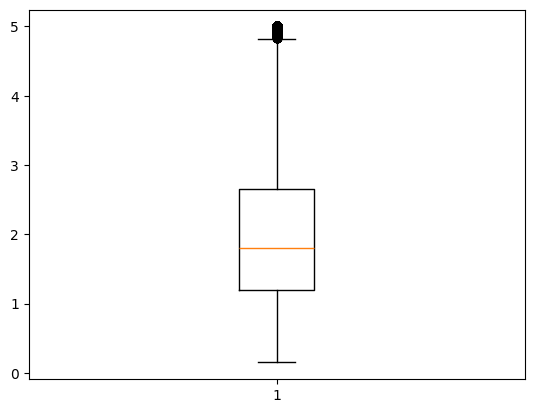

In [68]:
plt.boxplot(y)

Гистограмма и "ящик с усами" построенные по целевой переменной показывают, что выбросы в данных отсутсвуют.

## Построение корреляционной матрицы

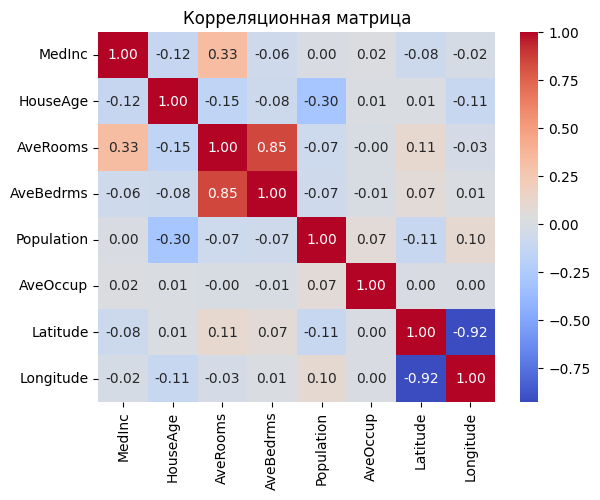

In [69]:
correlation_matrix = X.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

Исходя их матрицы, можно сделать вывод о том, что сильная связь присутствует между такими показателями как "AveBedrms" (т.е. среднее количество спален) и "AveRooms" (т.е. среднее количество комнат в целом) что логично. Также присутствует обратная связь между широтой и долготой.

<br>
Уберем из датасета "AveBedrms" и обучим новую модель.
<br>
P.S. Пробовал убрать и координаты из модели, но стало только хуже, поэтому убрал только один признак.

In [70]:
data_2 = housing.data[ ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude'] ]

data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   Population  20640 non-null  float64
 4   AveOccup    20640 non-null  float64
 5   Latitude    20640 non-null  float64
 6   Longitude   20640 non-null  float64
dtypes: float64(7)
memory usage: 1.1 MB


Пропусков нет.

In [71]:
X_2 = data_2
y_2 = housing.target

In [72]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [73]:
model_2 = LinearRegression()
model_2.fit( X_train_2, y_train_2 )

LinearRegression()

In [74]:
y_pred_2 = model_2.predict(X_test_2)

In [75]:
MSE_2 = mean_squared_error(y_test_2, y_pred_2)
RMSE_2 = math.sqrt(MSE_2)
print(f"RMSE_2: {RMSE_2:.4f}")

RMSE_2: 0.7398


In [76]:
r2_2 = r2_score(y_test_2, y_pred_2)
print(f"R²_2: {r2_2}")

R²_2: 0.5823239094526445


Значения метрик практически не изменились

## Исследуем оставшиеся признаки на выбросы

### Убираем выбросы из датасета

In [77]:
def iqr_filter_with_index(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] >= lower_bound) & (df[column] <= upper_bound)

# Создаем маску, изначально все True
mask = pd.Series([True] * len(housing.data), index=housing.data.index)

# Применяем фильтры последовательно
mask &= iqr_filter_with_index(housing.data, 'MedInc')
mask &= iqr_filter_with_index(housing.data, 'HouseAge')
mask &= iqr_filter_with_index(housing.data, 'AveRooms')
mask &= iqr_filter_with_index(housing.data, 'Population')
mask &= iqr_filter_with_index(housing.data, 'AveOccup')
mask &= iqr_filter_with_index(housing.data, 'Latitude')
mask &= iqr_filter_with_index(housing.data, 'Longitude')

# Применяем маску к обоим массивам
X_3 = housing.data[mask]
y_3 = housing.target[mask]

X_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17825 entries, 2 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      17825 non-null  float64
 1   HouseAge    17825 non-null  float64
 2   AveRooms    17825 non-null  float64
 3   AveBedrms   17825 non-null  float64
 4   Population  17825 non-null  float64
 5   AveOccup    17825 non-null  float64
 6   Latitude    17825 non-null  float64
 7   Longitude   17825 non-null  float64
dtypes: float64(8)
memory usage: 1.2 MB


### Построим модель на даннных без выбросов

In [78]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

In [79]:
model_3 = LinearRegression()
model_3.fit( X_train_3, y_train_3 )

LinearRegression()

In [80]:
y_pred_3 = model_3.predict(X_test_3)

In [81]:
MSE_3 = mean_squared_error(y_test_3, y_pred_3)
RMSE_3 = math.sqrt(MSE_3)
print(f"RMSE_3: {RMSE_3:.4f}")

RMSE_3: 0.6655


In [82]:
r2_3 = r2_score(y_test_3, y_pred_3)
print(f"R²_3: {r2_3}")

R²_3: 0.6257648290936383


Значения метрик немного улучшились

## Математические преобразования над признаками

Возьмем логарифм от признака "MedInc" в связи с ассиметрией распределения (видно из гистограммы выше).

In [83]:
X_4 = X_3
y_4 = y_3
X_4['MedInc'] = np.log(X_4['MedInc'])

/var/folders/6w/fwb_07rx7c3_dpz1j_x3zv880000gn/T/ipykernel_1715/77640041.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_4['MedInc'] = np.log(X_4['MedInc'])


In [84]:
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, test_size=0.2, random_state=42)

In [85]:
model_4 = LinearRegression()
model_4.fit( X_train_4, y_train_4 )

LinearRegression()

In [86]:
y_pred_4 = model_4.predict(X_test_4)

In [87]:
MSE_4 = mean_squared_error(y_test_4, y_pred_4)
RMSE_4 = math.sqrt(MSE_4)
print(f"RMSE_4: {RMSE_4:.4f}")

RMSE_4: 0.7054


In [88]:
r2_4 = r2_score(y_test_4, y_pred_4)
print(f"R²_3: {r2_4}")

R²_3: 0.5795413150509064


# Вывод по проделанной работе

В ходе данного домашнего задания был проведен ряд обработки данных для получения более качественной модели линейной регрессии, а именно:

1. Построена модель на основе всех неизмененных признаков
2. Модель на основе признаков, отобранных по значениям корреляций (убрали признак AveBedrms)
3. Модель без AveBedrms, с чисткой датасета от выбросов
4. Модель с математической обработкой признака MedInd (взят натуральный логарифм)

Полученнные метрики моделей представлены ниже:

| Модель | RMSE | R^2 |
|--------|------|--------|
| На основе всех неизмененных признаков | 0.7456 | 0.5757 |
| На основе признаков, отобранных по значениям корреляций | 0.7398 | 0.5823 |
| Модель без AveBedrms, с чисткой датасета от выбросов | 0.6655 | 0.6257 |
| Модель с математической обработкой признака MedInd (взят натуральный логарифм) | 0.7054 | 0.5795 |


Чистка данных от выбросов немного помогла улучшить качество, но после математических преобразований качество вернулось к изначальному варианту. Проблема скорее всего связана с нелинейностью данных в данном датасете и для лучшего прогнозирования неободимо использовать другую модель.
